# ETL – Przygotowanie danych do forecastingu produkcji PV w Polsce

Opis pliku `fw_pv.xlsx` – co oznaczają dane?

Plik zawiera dwie kolumny:
| Kolumna | Znaczenie |
|---|---|
| `Sumaryczna generacja Źródeł Wiatrowych his-wlk-cal` | Łączna produkcja energii ze wszystkich farm wiatrowych w Polsce w danej godzinie |
| `Sumaryczna generacja Źródeł Fotowoltaicznych his-wlk-cal` | Łączna produkcja energii ze wszystkich instalacji PV w Polsce w danej godzinie |

**Jednostka: MWh (megawatogodziny)** – ilość energii wytworzonej w ciągu danej godziny przez wszystkie instalacje danego typu w Polsce łącznie. Ponieważ horyzont czasowy to 1 godzina, wartości te są równoważne średniej mocy wyrażonej w MW.

Przedrostek `his-wlk-cal` oznacza *historical – large-scale calibrated* (dane historyczne skalibrowane na skalę krajową).

Źródło danych: platforma PSE (Polskie Sieci Elektroenergetyczne): https://raporty.pse.pl/

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import unicodedata

DATA_DIR = '../dane'
OUTPUT_DIR = '../dane_merged'

## 1. Wczytanie danych produkcji energii (fw_pv.xlsx)

In [2]:
df_energy = pd.read_excel(os.path.join(DATA_DIR, 'fw_pv.xlsx'), usecols=[0,2], names=['Date', 'PV_MWh'])
df_energy.head()

,Date,PV_MWh
0,2022-10-09T00:00:00.000Z,0.0
1,2022-10-09T01:00:00.000Z,0.0
2,2022-10-09T02:00:00.000Z,0.0
3,2022-10-09T03:00:00.000Z,0.0
4,2022-10-09T04:00:00.000Z,0.0


In [3]:
df_energy.dtypes

Date          str
PV_MWh    float64
dtype: object

In [4]:
df_energy['Date'] = pd.to_datetime(df_energy['Date'], utc=True, yearfirst=True).dt.tz_localize(None)
df_energy.dtypes

Date      datetime64[us]
PV_MWh           float64
dtype: object

datetime64[us] - data is stored as a 64-bit integer and precision of the timestamp is microseconds [us]

In [5]:
duplicated_rows = df_energy.duplicated('Date').sum()
if(duplicated_rows > 0):
    raise ValueError(f'Found {duplicated_rows} duplicated rows in df_energy. Need to drop them.')
print('No duplicated rows in df_energy.\n')

original_shape = df_energy.shape
print(f'Shape: {original_shape}')
print(f'Date range: {df_energy["Date"].min()} - {df_energy["Date"].max()}\n')
print(f'Missing values:\n{df_energy.isnull().sum()}')

No duplicated rows in df_energy.

Shape: (31556, 2)
Date range: 2022-10-09 00:00:00 - 2026-05-15 23:00:00

Missing values:
Date       0
PV_MWh    67
dtype: int64


In [6]:
def get_missing_indices(df):
    bool_missing = df['PV_MWh'].isnull()
    missing_indices = np.where(bool_missing)[0]
    return missing_indices
missing_indices = get_missing_indices(df_energy)

In [7]:
df_energy.iloc[missing_indices]

,Date,PV_MWh
25388,2025-08-31 23:00:00,NaN
29972,2026-03-10 23:00:00,NaN
31491,2026-05-13 07:00:00,NaN
31492,2026-05-13 08:00:00,NaN
31493,2026-05-13 09:00:00,NaN
...,...,...
31551,2026-05-15 19:00:00,NaN
31552,2026-05-15 20:00:00,NaN
31553,2026-05-15 21:00:00,NaN
31554,2026-05-15 22:00:00,NaN


In [8]:
missing_indices

array([25388, 29972, 31491, 31492, 31493, 31494, 31495, 31496, 31497,
       31498, 31499, 31500, 31501, 31502, 31503, 31504, 31505, 31506,
       31507, 31508, 31509, 31510, 31511, 31512, 31513, 31514, 31515,
       31516, 31517, 31518, 31519, 31520, 31521, 31522, 31523, 31524,
       31525, 31526, 31527, 31528, 31529, 31530, 31531, 31532, 31533,
       31534, 31535, 31536, 31537, 31538, 31539, 31540, 31541, 31542,
       31543, 31544, 31545, 31546, 31547, 31548, 31549, 31550, 31551,
       31552, 31553, 31554, 31555])

We've got missing values for produced PV at the end of the file but also 2 missing in the middle. 

TODO: why do we have the NaN in the middle at all? sth wrong with the api? 2 rows in the original .xlsx have NaN for both columns the wind and pv

Odcinamy końcowe wiersze na których nie chcemy wykonać interpolacji, czyli te ostatnie NaN,zeby nie tworzyć niewłaściwych trendów. 

In [9]:
last_index = df_energy['PV_MWh'].last_valid_index()  # sprawdza od końca dataframe'u idzie do góry aż znajdzie pierwszą wartość nie-NaN i zwraca jej indeks
last_index

31490

In [10]:
df_energy.drop(df_energy.index[last_index+1:], axis=0, inplace=True)
get_missing_indices(df_energy)

array([25388, 29972])

Pozostałe wiersze interpolujemy.

In [11]:
df_energy.iloc[25390]

Date      2025-09-01 01:00:00
PV_MWh                    0.0
Name: 25390, dtype: object

In [12]:
df_energy['PV_MWh'] = df_energy['PV_MWh'].interpolate(method='linear', limit=2)
df_energy.isna().sum()  

Date      0
PV_MWh    0
dtype: int64

In [13]:
df_energy['PV_MWh'].describe()

count    31491.000000
mean      1840.372372
std       2826.543810
min          0.000000
25%          0.000000
50%        102.413000
75%       2851.906125
max      13682.331250
Name: PV_MWh, dtype: float64

We have many zero producing hours. 25% of time we do not produce energy at all.

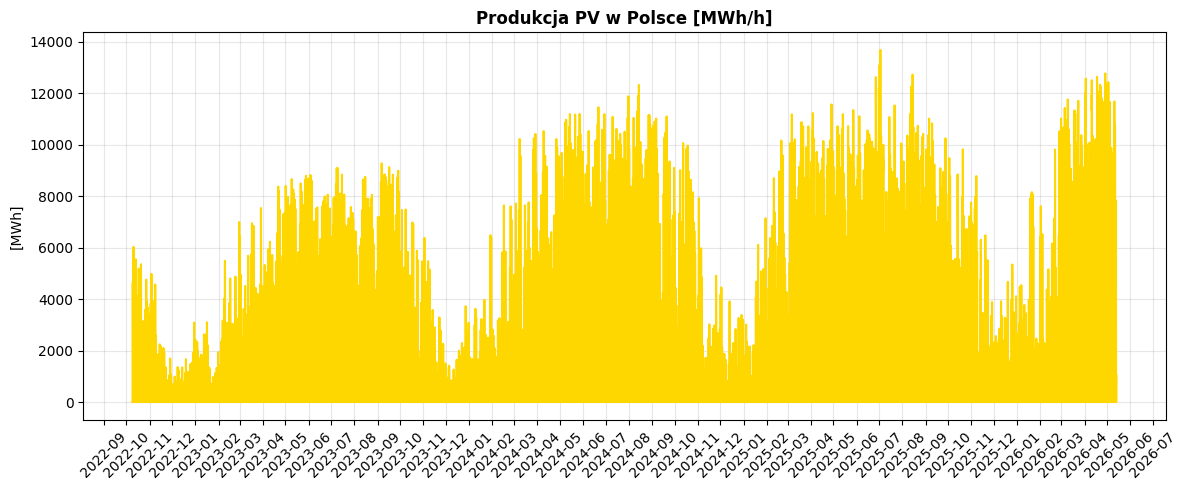

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_energy['Date'], df_energy['PV_MWh'], color='gold', label='PV Production')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

ax.set_title('Produkcja PV w Polsce [MWh/h]', fontweight='bold')
ax.set_ylabel('[MWh]')
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()

Widzimy duże spadki produkcji energii fotowoltaicznej w zimowych miesiącach i taki trend jest utrzymywany we wszystkich latach. Dodatkowo, prodkcja energii z roku na rok rośnie, widzimy, że następne lata w najwyższe dni produkcyjne, przewyższają najwyższe notowania z poprzedniego roku.

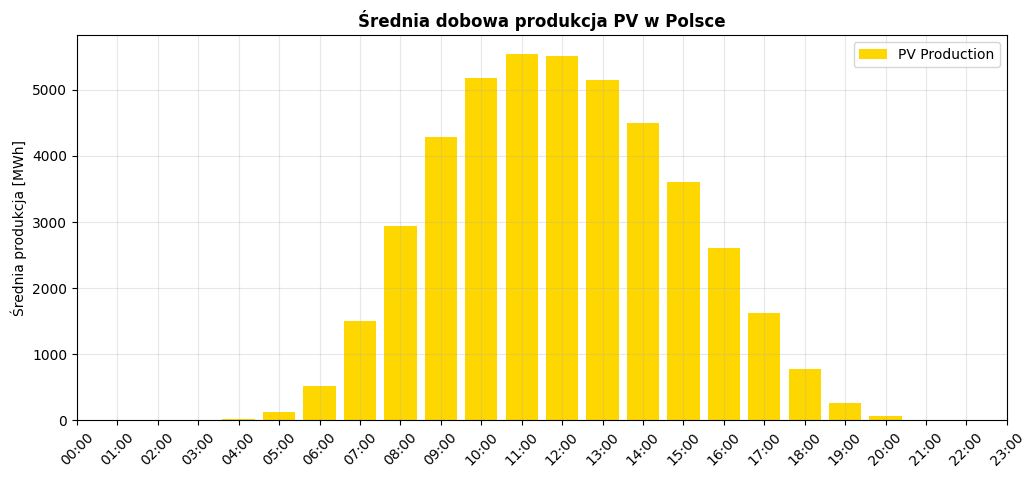

In [15]:
production_by_hour = df_energy.groupby(df_energy['Date'].dt.hour)['PV_MWh'].mean()

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(production_by_hour.index, production_by_hour.values, color='gold', label='PV Production')
ax.set_xlim(0, 23)
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45)
ax.set_title('Średnia dobowa produkcja PV w Polsce', fontweight='bold', fontsize=12)
ax.set_ylabel('Średnia produkcja [MWh]')
ax.grid(True, alpha=0.3)
ax.legend()

Jak można by się spodziewać, produkcja energii fotowoltaicznej koncentruje się w godzinach najbardziej naświetlonych w ciągu dnia. Im 'większe' słońce, tym większa produkcja.

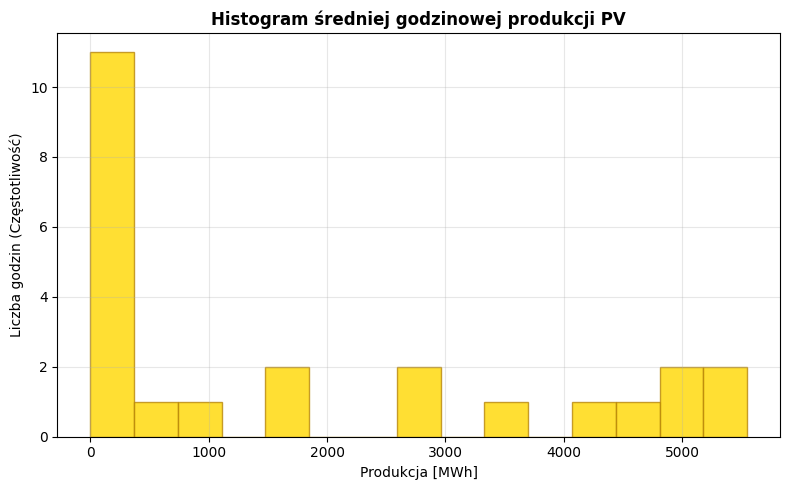

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(production_by_hour.values, bins=15, color='gold', edgecolor='darkgoldenrod', alpha=0.8)
ax.set_title('Histogram średniej godzinowej produkcji PV', fontweight='bold', fontsize=12)
ax.set_xlabel('Produkcja [MWh]')
ax.set_ylabel('Liczba godzin (Częstotliwość)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Widzimy, że przez największą część doby nie mamy produkcji energii fotowoltaicznej. Nastepnie ilość produkcji godzinowej jest dość rostrzelona na krańcach. Mamy albo głównie produkcję poniżej 2000 MWh albo około i powyżej 5000 MWh.

## 2. Wczytanie danych pogodowych (16 województw)

In [17]:
PROVINCE_CODES = {
    'dolnośląskie':         'dol',
    'kujawsko-pomorskie':   'kup',
    'lubelskie':            'lub',
    'lubuskie':             'lubus',
    'łódzkie':              'lod',
    'małopolskie':          'mal',
    'mazowieckie':          'maz',
    'opolskie':             'opo',
    'podkarpackie':         'pdk',
    'podlaskie':            'pdl',
    'pomorskie':            'pom',
    'śląskie':              'sla',
    'świętokrzyskie':       'swt',
    'warmińsko-mazurskie':  'war',
    'wielkopolskie':        'wie',
    'zachodnio-pomorskie':  'zpom',
}

WEATHER_FEATURES = [
    'Avg_Air_Temp',
    'Rel_Air_Humidity',
    'Rainfall',
    'Snowfall',
    'Avg_Soil_Temp',
    'Soil_Humidity',
    'Wind_Speed',
    'Dew_Point',
    'Solar_Radiation',
]

weather_dfs = []

for filename in sorted(os.listdir(DATA_DIR)):
    if not filename.endswith('.csv'):
        continue
    province_name = filename.replace('.csv', '')
    province_name_nfc = unicodedata.normalize('NFC', province_name) # Normalize to NFC Unicode form
    code = PROVINCE_CODES.get(province_name_nfc)
    if code is None:
        print(f'  WARNING: no code for "{province_name_nfc}", skipping')
        continue

    df = pd.read_csv(os.path.join(DATA_DIR, filename), parse_dates=['Date'])
    df = df[['Date'] + WEATHER_FEATURES].copy()
    df.columns = ['Date'] + [f'{code}_{feat}' for feat in WEATHER_FEATURES]

    weather_dfs.append(df)
    print(f'{province_name_nfc:20s}[{code:5s}] {len(df)} rows, {df["Date"].min().date()} → {df["Date"].max().date()}')

print(f'\nLoaded {len(weather_dfs)} province datasets')

dolnośląskie        [dol  ] 10872 rows, 2025-02-15 → 2026-05-13
kujawsko-pomorskie  [kup  ] 10872 rows, 2025-02-15 → 2026-05-13
lubelskie           [lub  ] 10872 rows, 2025-02-15 → 2026-05-13
lubuskie            [lubus] 10872 rows, 2025-02-15 → 2026-05-13
mazowieckie         [maz  ] 10872 rows, 2025-02-15 → 2026-05-13
małopolskie         [mal  ] 10872 rows, 2025-02-15 → 2026-05-13
opolskie            [opo  ] 10872 rows, 2025-02-15 → 2026-05-13
podkarpackie        [pdk  ] 10872 rows, 2025-02-15 → 2026-05-13
podlaskie           [pdl  ] 10872 rows, 2025-02-15 → 2026-05-13
pomorskie           [pom  ] 10872 rows, 2025-02-15 → 2026-05-13
śląskie             [sla  ] 10872 rows, 2025-02-15 → 2026-05-13
świętokrzyskie      [swt  ] 10872 rows, 2025-02-15 → 2026-05-13
warmińsko-mazurskie [war  ] 10872 rows, 2025-02-15 → 2026-05-13
wielkopolskie       [wie  ] 10872 rows, 2025-02-15 → 2026-05-13
zachodnio-pomorskie [zpom ] 11952 rows, 2025-01-01 → 2026-05-13
łódzkie             [lod  ] 10872 rows, 

In [18]:
dtypes_lists = (tuple(_df.dtypes) for _df in weather_dfs)
if(len(set(dtypes_lists))==1):
    print("All datasets have consistent data types.")
else:
    print("Inconsistent data types found across datasets.")

All datasets have consistent data types.


In [19]:
from functools import reduce

df_weather = reduce(lambda a, b: pd.merge(a, b, on='Date', how='inner'), weather_dfs)
df_weather = df_weather.sort_values('Date').reset_index(drop=True)  # creating new index for merged dataset

print(f'Wide weather dataframe shape: {df_weather.shape}')
print(f'Date range: {df_weather["Date"].min()} → {df_weather["Date"].max()}')
print(f'Total NaN: {df_weather.isnull().sum().sum()}')
df_weather.head()

Wide weather dataframe shape: (10872, 145)
Date range: 2025-02-15 00:00:00 → 2026-05-13 23:00:00
Total NaN: 0


,Date,dol_Avg_Air_Temp,dol_Rel_Air_Humidity,dol_Rainfall,dol_Snowfall,dol_Avg_Soil_Temp,dol_Soil_Humidity,dol_Wind_Speed,dol_Dew_Point,dol_Solar_Radiation,...,zpom_Solar_Radiation,lod_Avg_Air_Temp,lod_Rel_Air_Humidity,lod_Rainfall,lod_Snowfall,lod_Avg_Soil_Temp,lod_Soil_Humidity,lod_Wind_Speed,lod_Dew_Point,lod_Solar_Radiation
0,2025-02-15 00:00:00,-3.24,89,0.0,0,0.0,21,2.08,-4.69,-6,...,-4,-4.80,84,0.0,0,0.0,23,3.43,-7.04,14
1,2025-02-15 01:00:00,-2.62,90,0.0,0,0.0,21,1.71,-3.92,0,...,-3,-4.25,82,0.0,0,0.0,23,3.18,-6.85,-8
2,2025-02-15 02:00:00,-2.20,94,0.0,0,0.0,21,1.41,-3.02,-10,...,-3,-4.17,80,0.0,0,0.0,24,2.78,-6.95,-9
3,2025-02-15 03:00:00,-2.17,90,0.0,0,0.0,21,1.21,-3.52,-5,...,-4,-5.06,84,0.0,0,0.0,24,2.75,-7.22,-7
4,2025-02-15 04:00:00,-2.50,89,0.0,0,0.0,21,1.33,-4.02,-2,...,-3,-6.57,93,0.0,0,0.0,24,2.58,-7.48,-8


## 3. Połączenie danych pogodowych z danymi produkcji

In [20]:
df = pd.merge(df_weather, df_energy, on='Date', how='inner')
print(f'Merged shape: {df.shape}')
print(f'Missing values:')
pd.DataFrame(df.isnull().sum(), columns=[ 'Missing']).filter(items=['Missing']).T


Merged shape: (10853, 146)
Missing values:


,Date,dol_Avg_Air_Temp,dol_Rel_Air_Humidity,dol_Rainfall,dol_Snowfall,dol_Avg_Soil_Temp,dol_Soil_Humidity,dol_Wind_Speed,dol_Dew_Point,dol_Solar_Radiation,...,lod_Avg_Air_Temp,lod_Rel_Air_Humidity,lod_Rainfall,lod_Snowfall,lod_Avg_Soil_Temp,lod_Soil_Humidity,lod_Wind_Speed,lod_Dew_Point,lod_Solar_Radiation,PV_MWh
Missing,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 4. Inżynieria cech – cechy czasowe


Wyciągamy cechy czasowe jak: godzina, dzień tygodnia, dzień roku do nowych kolumn.  
Dodatkowo dodajemy kolumny czasu kodowane cyklicznie zamiast liniowo: (model nie będzie widział np. godziny 23:00 i 0:00 jako dwie praktycznie przeciwne wartości, tylko jako bliskie sobie momenty czasu, lepsze zrozumienie czym jest dana godzina dla modelu, szczególnie w przypadku energii fotowoltaicznej; tak samo zrobimy dla dniami w roku = zmiany pór roku mają znaczenie dla produkowanej energii tak jak to widzieliśmy na wykresach wcześniej)
- godzina doby → `hour_sin`, `hour_cos`
- dzień roku → `dayofyear_sin`, `dayofyear_cos`
- dzień tygodnia → `weekday_sin`, `weekday_cos`

Oprócz danych per województwo, dodajemy agregaty krajowe dla kluczowych zmiennych. Modele mogą z nich skorzystać, gdy regionalny sygnał jest silny ale jednolity.

In [21]:
df['hour']       = df['Date'].dt.hour
df['dayofweek']  = df['Date'].dt.dayofweek    # 0=Monday, 6=Sunday
df['dayofyear']  = df['Date'].dt.dayofyear
df['month']      = df['Date'].dt.month
df['year']       = df['Date'].dt.year

def cyclic_encode(series: pd.Series, period: int):
    sin_vals = np.sin(2 * np.pi * series / period)
    cos_vals = np.cos(2 * np.pi * series / period)
    return sin_vals, cos_vals

# enkodowanie cykliczne
df['hour_sin'],      df['hour_cos']      = cyclic_encode(df['hour'],      period=24)
df['weekday_sin'],   df['weekday_cos']   = cyclic_encode(df['dayofweek'], period=7)
df['dayofyear_sin'], df['dayofyear_cos'] = cyclic_encode(df['dayofyear'], period=365)
df['month_sin'],     df['month_cos']     = cyclic_encode(df['month'],     period=12)

# flagi binarne
df['is_night'] = ((df['hour'] < 6) | (df['hour'] >= 21)).astype(int)
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

print(f'Total columns now: {df.shape[1]}')

Total columns now: 161


In [22]:
codes = list(PROVINCE_CODES.values())

for feat in WEATHER_FEATURES:
    cols = [f'{c}_{feat}' for c in codes if f'{c}_{feat}' in df.columns]
    df[f'PL_{feat}_mean'] = df[cols].mean(axis=1)
    df[f'PL_{feat}_std']  = df[cols].std(axis=1)

spatial_cols = [c for c in df.columns if c.startswith('PL_')]
print(f'Added {len(spatial_cols)} aggregate columns')
print(spatial_cols)

Added 18 aggregate columns
['PL_Avg_Air_Temp_mean', 'PL_Avg_Air_Temp_std', 'PL_Rel_Air_Humidity_mean', 'PL_Rel_Air_Humidity_std', 'PL_Rainfall_mean', 'PL_Rainfall_std', 'PL_Snowfall_mean', 'PL_Snowfall_std', 'PL_Avg_Soil_Temp_mean', 'PL_Avg_Soil_Temp_std', 'PL_Soil_Humidity_mean', 'PL_Soil_Humidity_std', 'PL_Wind_Speed_mean', 'PL_Wind_Speed_std', 'PL_Dew_Point_mean', 'PL_Dew_Point_std', 'PL_Solar_Radiation_mean', 'PL_Solar_Radiation_std']


## 5. Podział na zbiór treningowy i walidacyjny
Zbiór walidacyjny powinien zawierać 5-7 dni, więc wybrano 7 pełnych ostatnich dni.

In [23]:
df.tail()

,Date,dol_Avg_Air_Temp,dol_Rel_Air_Humidity,dol_Rainfall,dol_Snowfall,dol_Avg_Soil_Temp,dol_Soil_Humidity,dol_Wind_Speed,dol_Dew_Point,dol_Solar_Radiation,...,PL_Avg_Soil_Temp_mean,PL_Avg_Soil_Temp_std,PL_Soil_Humidity_mean,PL_Soil_Humidity_std,PL_Wind_Speed_mean,PL_Wind_Speed_std,PL_Dew_Point_mean,PL_Dew_Point_std,PL_Solar_Radiation_mean,PL_Solar_Radiation_std
10848,2026-05-13 02:00:00,4.58,89,0.0,0,7.78,23,3.22,3.03,1,...,8.702500,0.542089,21.0000,1.966384,3.129375,0.945829,3.516875,1.677497,-24.2500,19.108462
10849,2026-05-13 03:00:00,5.43,86,0.0,0,7.69,23,2.82,3.35,-3,...,8.171875,0.537887,20.8125,1.973787,3.176250,0.862762,3.503125,1.594711,-21.3750,15.226621
10850,2026-05-13 04:00:00,5.88,85,0.0,0,7.63,23,2.73,3.61,-14,...,7.721250,0.604526,20.7500,1.983263,3.383125,0.981364,3.516250,1.556641,-18.2500,13.208583
10851,2026-05-13 05:00:00,6.09,83,0.0,0,7.50,23,2.89,3.55,-13,...,7.350625,0.606998,20.6875,1.956826,3.480000,0.979925,3.501875,1.474608,-13.5625,13.947371
10852,2026-05-13 06:00:00,6.46,80,0.0,0,7.37,23,3.04,3.33,-10,...,7.232500,0.522666,20.6250,1.962142,3.693125,0.952111,3.699375,1.385710,16.4375,17.877243


In [24]:
split_date = df['Date'].max() - pd.Timedelta(days=7)
train_df = df[df['Date'] < split_date].copy().reset_index(drop=True)
test_df  = df[df['Date'] >= split_date].copy().reset_index(drop=True)
print(f'Zbiór treningowy:  {len(train_df):>6} godzin  ({train_df["Date"].min()} - {train_df["Date"].max()})')
print(f'Zbiór walidacyjny: {len(test_df):>6} godzin  ({test_df["Date"].min()} - {test_df["Date"].max()})')
print(f'\nProporcja: {len(train_df)/len(df)*100:.1f}% train / {len(test_df)/len(df)*100:.1f}% val')

Zbiór treningowy:   10684 godzin  (2025-02-15 00:00:00 - 2026-05-06 05:00:00)
Zbiór walidacyjny:    169 godzin  (2026-05-06 06:00:00 - 2026-05-13 06:00:00)

Proporcja: 98.4% train / 1.6% val


## 7. Eksploracja danych

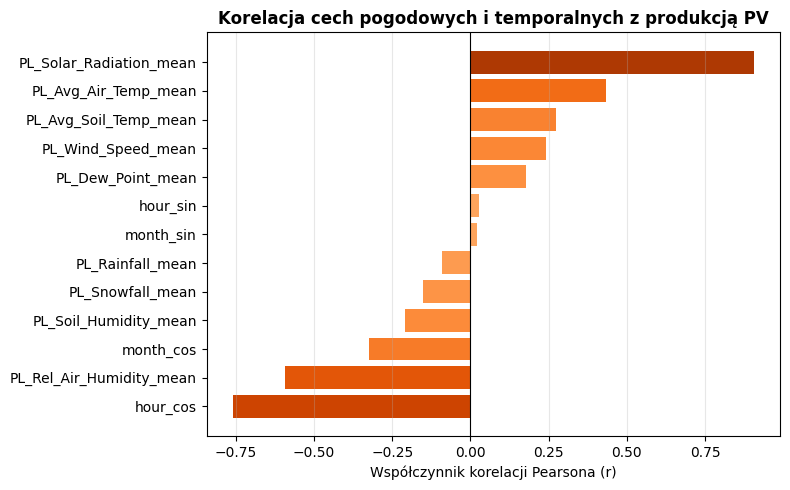

In [25]:
corr_cols = [f'PL_{f}_mean' for f in WEATHER_FEATURES] + ['hour_sin', 'hour_cos', 'month_sin', 'month_cos']
corr_matrix = train_df[corr_cols + ['PV_MWh']].corr()

fig, ax = plt.subplots(figsize=(8, 5))
corr_target = corr_matrix['PV_MWh'].drop(['PV_MWh'])
corr_target_sorted = corr_target.sort_values()

bars = ax.barh(corr_target_sorted.index, corr_target_sorted.values,
               color=[plt.get_cmap('Oranges')(0.4 + 0.5 * abs(v)) for v in corr_target_sorted.values])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Korelacja cech pogodowych i temporalnych z produkcją PV', fontsize=12, fontweight='bold')
ax.set_xlabel('Współczynnik korelacji Pearsona (r)')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

Na wykresie widzimy jak średnie pogodowe dla polski oraz cykliczne cechy czasowe są skorelowane z wartością produkcji energii fotowoltaicznej.

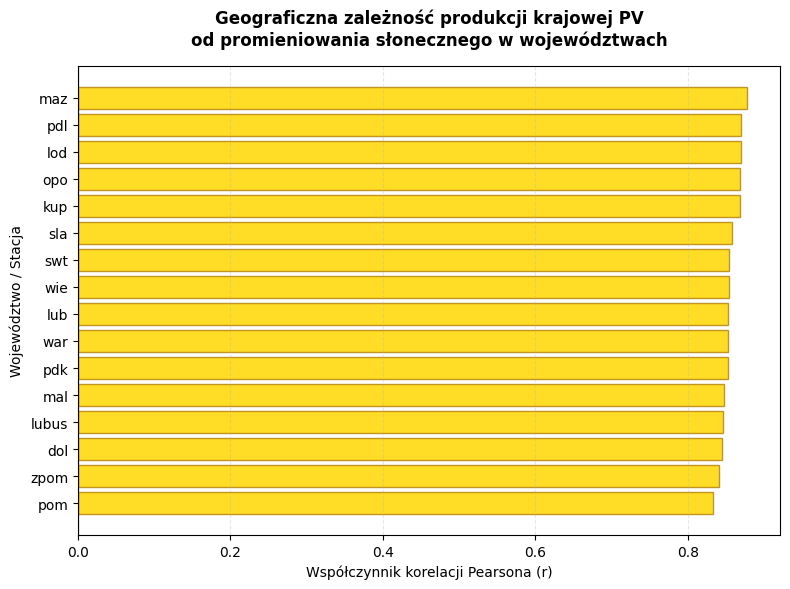

Województwa, których warunki pogodowe mają największy wpływ na krajowe PV:
maz    0.876978
pdl    0.869547
lod    0.869440
opo    0.868722
kup    0.868301
Name: PV_MWh, dtype: float64


In [26]:
import matplotlib.pyplot as plt

solar_cols = [f'{c}_Solar_Radiation' for c in codes]
pv_solar_corrs = train_df[solar_cols + ['PV_MWh']].corr()['PV_MWh'].drop('PV_MWh')

pv_solar_corrs.index = [c.replace('_Solar_Radiation', '') for c in pv_solar_corrs.index]
pv_solar_corrs_sorted = pv_solar_corrs.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(pv_solar_corrs_sorted.index, pv_solar_corrs_sorted.values, 
        color='gold', alpha=0.85, edgecolor='darkgoldenrod')

ax.axvline(0, color='black', linewidth=0.8)

ax.set_title('Geograficzna zależność produkcji krajowej PV\nod promieniowania słonecznego w województwach', 
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Współczynnik korelacji Pearsona (r)', fontsize=10)
ax.set_ylabel('Województwo / Stacja', fontsize=10)
ax.grid(True, alpha=0.3, axis='x', linestyle='--')

plt.tight_layout()
plt.show()

print('Województwa, których warunki pogodowe mają największy wpływ na krajowe PV:')
print(pv_solar_corrs.sort_values(ascending=False).head(5))

In [27]:
# ## 8. Definicja zestawów cech dla modeli

# # Tworzymy dwa zestawy: jeden do predykcji **PV**, drugi do predykcji **FW**
# # Province-level columns
# all_province_cols = [c for c in df.columns
#                      if any(c.startswith(f'{code}_') for code in codes)]

# # Spatial aggregates
# spatial_agg_cols = [c for c in df.columns if c.startswith('PL_')]

# # Temporal features
# temporal_cols = [
#     'hour_sin', 'hour_cos',
#     'weekday_sin', 'weekday_cos',
#     'dayofyear_sin', 'dayofyear_cos',
#     'month_sin', 'month_cos',
#     'is_night', 'is_weekend',
# ]

# # PV model: solar radiation & temperature are the main drivers;
# #            include all province-level features + temporal
# PV_FEATURES = (
#     [c for c in all_province_cols if any(s in c for s in
#      ['Solar_Radiation', 'Avg_Air_Temp', 'Rel_Air_Humidity', 'Snowfall'])]
#     + [f'PL_mean_{f}' for f in WEATHER_FEATURES]
#     + temporal_cols
# )

# # FW model: wind speed, temperature (air density) are the main drivers
# FW_FEATURES = (
#     [c for c in all_province_cols if any(s in c for s in
#      ['Wind_Speed', 'Avg_Air_Temp', 'Rainfall'])]
#     + [f'PL_mean_{f}' for f in WEATHER_FEATURES]
#     + temporal_cols
# )

# print(f'Cechy dla modelu PV: {len(PV_FEATURES)} kolumn')
# print(f'Cechy dla modelu FW: {len(FW_FEATURES)} kolumn')

# # Full feature set (all province cols + aggregates + temporal)
# ALL_FEATURES = sorted(set(all_province_cols + spatial_agg_cols + temporal_cols))
# print(f'Pełny zestaw cech: {len(ALL_FEATURES)} kolumn')

## 9. Zapis do pliku

In [28]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
out_full  = os.path.join(OUTPUT_DIR, 'dataset_full.csv')
out_train = os.path.join(OUTPUT_DIR, 'dataset_train.csv')
out_val   = os.path.join(OUTPUT_DIR, 'dataset_val.csv')

df.to_csv(out_full,  index=False, encoding='utf-8')
train_df.to_csv(out_train, index=False, encoding='utf-8')
test_df.to_csv(out_val,   index=False, encoding='utf-8')

print(f'Zapisano:')
print(f'  {out_full}  ({os.path.getsize(out_full)/1e6:.1f} MB)')
print(f'  {out_train} ({os.path.getsize(out_train)/1e6:.1f} MB)')
print(f'  {out_val}   ({os.path.getsize(out_val)/1e6:.1f} MB)')

Zapisano:
  ../dane_merged/dataset_full.csv  (11.0 MB)
  ../dane_merged/dataset_train.csv (10.8 MB)
  ../dane_merged/dataset_val.csv   (0.2 MB)


In [29]:
df.shape

(10853, 179)

In [32]:
for col in df.columns:
    print(col)

Date
dol_Avg_Air_Temp
dol_Rel_Air_Humidity
dol_Rainfall
dol_Snowfall
dol_Avg_Soil_Temp
dol_Soil_Humidity
dol_Wind_Speed
dol_Dew_Point
dol_Solar_Radiation
kup_Avg_Air_Temp
kup_Rel_Air_Humidity
kup_Rainfall
kup_Snowfall
kup_Avg_Soil_Temp
kup_Soil_Humidity
kup_Wind_Speed
kup_Dew_Point
kup_Solar_Radiation
lub_Avg_Air_Temp
lub_Rel_Air_Humidity
lub_Rainfall
lub_Snowfall
lub_Avg_Soil_Temp
lub_Soil_Humidity
lub_Wind_Speed
lub_Dew_Point
lub_Solar_Radiation
lubus_Avg_Air_Temp
lubus_Rel_Air_Humidity
lubus_Rainfall
lubus_Snowfall
lubus_Avg_Soil_Temp
lubus_Soil_Humidity
lubus_Wind_Speed
lubus_Dew_Point
lubus_Solar_Radiation
maz_Avg_Air_Temp
maz_Rel_Air_Humidity
maz_Rainfall
maz_Snowfall
maz_Avg_Soil_Temp
maz_Soil_Humidity
maz_Wind_Speed
maz_Dew_Point
maz_Solar_Radiation
mal_Avg_Air_Temp
mal_Rel_Air_Humidity
mal_Rainfall
mal_Snowfall
mal_Avg_Soil_Temp
mal_Soil_Humidity
mal_Wind_Speed
mal_Dew_Point
mal_Solar_Radiation
opo_Avg_Air_Temp
opo_Rel_Air_Humidity
opo_Rainfall
opo_Snowfall
opo_Avg_Soil_Temp
o

Ostateczne cechy w datasecie:
- cechy pogodowe dla każdego z województw
- dla każdej zmiennej pogodowej cechy dla Polski: `PL_mean_*` i `PL_std_*`
- cechy czasowe: sin/cos: godzina, dzień roku, miesiąc, dzień tygodnia + flagi (czy noc/dzień, czy weekend)